In [4]:
import torch
import cv2

print(f"PyTorch: {torch.__version__}")
# MPS ist Apples GPU-Schnittstelle
print(f"MPS verfügbar: {torch.backends.mps.is_available()}") # Metal Performance Shaders (MPS)
print(f"OpenCV: {cv2.__version__}")

PyTorch: 2.11.0
MPS verfügbar: True
OpenCV: 4.13.0


In [5]:
import os

data_dir = "/Users/fabianland/Documents/HS-Esslingen/6.Semester/machine_vision/lab/sign_language_interpreter/data/alphabet/asl_alphabet_train/asl_alphabet_train"
classes = sorted(os.listdir(data_dir))
print(classes)
print(f"Anzahl Klassen: {len(classes)}")

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Anzahl Klassen: 29


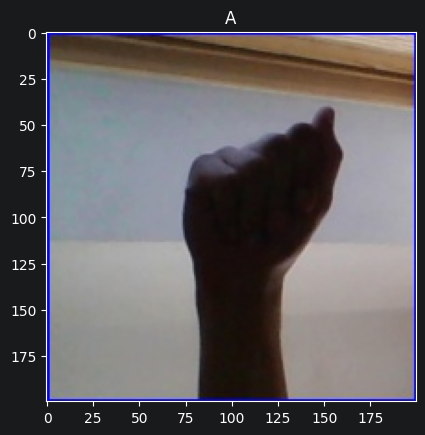

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

# Wähl dir eine Klasse aus und bau den Pfad zu einem Bild zusammen
class_name = "A"  # <- z.B. ein Buchstabe
class_path = os.path.join(data_dir, class_name)
images = os.listdir(class_path)

# Lade das erste Bild
img = Image.open(os.path.join(class_path, images[0]))

plt.imshow(img)
plt.title(class_name)
plt.show()

In [7]:
for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    num_images = len(os.listdir(class_path))
    print(f"{class_name}: {num_images} Bilder")

A: 3000 Bilder
B: 3000 Bilder
C: 3000 Bilder
D: 3000 Bilder
E: 3000 Bilder
F: 3000 Bilder
G: 3000 Bilder
H: 3000 Bilder
I: 3000 Bilder
J: 3000 Bilder
K: 3000 Bilder
L: 3000 Bilder
M: 3000 Bilder
N: 3000 Bilder
O: 3000 Bilder
P: 3000 Bilder
Q: 3000 Bilder
R: 3000 Bilder
S: 3000 Bilder
T: 3000 Bilder
U: 3000 Bilder
V: 3000 Bilder
W: 3000 Bilder
X: 3000 Bilder
Y: 3000 Bilder
Z: 3000 Bilder
del: 3000 Bilder
nothing: 3000 Bilder
space: 3000 Bilder


In [8]:
img = Image.open(os.path.join(data_dir, classes[0], images[0]))
print(img.size)

(200, 200)


In [9]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet-Normalisierung für ResNet
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)
print(f"Gesamtbilder: {len(dataset)}")
print(f"Klassen: {dataset.classes}")

Gesamtbilder: 87000
Klassen: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [10]:
from torch.utils.data import random_split
train_data, validation_data = random_split(dataset, [0.8, 0.2])
print(f"Trainingsbilder: {len(train_data)}")
print(f"Validationsbilder: {len(validation_data)}")

Trainingsbilder: 69600
Validationsbilder: 17400


In [11]:

from torch.utils.data import DataLoader
trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
validationloader = DataLoader(validation_data, batch_size=32, shuffle=True)

In [12]:
from torchvision import models
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
model1= models.resnet18(weights="DEFAULT")
print(model1)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
from torch import nn
model1.fc = nn.Linear(in_features=512, out_features=29) # letzte Schicht auf die 29 Klassen skalieren
print(model1.fc)

torch.device("mps")
model1 = model1.to("mps")
print(model1)

Linear(in_features=512, out_features=29, bias=True)
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

In [14]:
from torch import optim

criterion = nn.CrossEntropyLoss() # Loss Funktion
optimizer = optim.Adam(model1.parameters(), lr=0.001) # Optimizer


In [13]:
best_val_acc = 0.0

for epoch in range(10):
    # Training
    model1.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to("mps"), labels.to("mps")
        optimizer.zero_grad()
        outputs = model1(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model1.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in validationloader:
            images, labels = images.to("mps"), labels.to("mps")
            outputs = model1(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    print(f"Epoch {epoch+1}/10 | Loss: {running_loss/len(trainloader):.4f} | Val Accuracy: {val_acc*100:.2f}%")

    # Bestes Modell speichern
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model1.state_dict(), "model_resnet18_asl_best.pth")
        print(f"  -> Modell gespeichert (beste Val Accuracy: {best_val_acc*100:.2f}%)")

print("Training abgeschlossen!")

Epoch 1/10 | Loss: 0.0785 | Val Accuracy: 99.63%
  -> Modell gespeichert (beste Val Accuracy: 99.63%)
Epoch 2/10 | Loss: 0.0240 | Val Accuracy: 99.39%
Epoch 3/10 | Loss: 0.0193 | Val Accuracy: 99.77%
  -> Modell gespeichert (beste Val Accuracy: 99.77%)
Epoch 4/10 | Loss: 0.0097 | Val Accuracy: 99.93%
  -> Modell gespeichert (beste Val Accuracy: 99.93%)
Epoch 5/10 | Loss: 0.0109 | Val Accuracy: 99.99%
  -> Modell gespeichert (beste Val Accuracy: 99.99%)
Epoch 6/10 | Loss: 0.0097 | Val Accuracy: 100.00%
  -> Modell gespeichert (beste Val Accuracy: 100.00%)
Epoch 7/10 | Loss: 0.0090 | Val Accuracy: 99.90%
Epoch 8/10 | Loss: 0.0086 | Val Accuracy: 99.84%
Epoch 9/10 | Loss: 0.0057 | Val Accuracy: 99.94%
Epoch 10/10 | Loss: 0.0043 | Val Accuracy: 99.98%
Training abgeschlossen!


In [15]:
import torch
from torchvision import models, transforms
from torch import nn

model_live = models.resnet18(weights=None)
model_live.fc = nn.Linear(in_features=512, out_features=29)
model_live.load_state_dict(torch.load("model_resnet18_asl_best.pth", map_location=torch.device("mps")))
model_live = model_live.to("mps")
model_live.eval()
print("Modell geladen!")

Modell geladen!


In [16]:
import cv2
import torch
from torchvision import transforms

transform_live = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class_names = dataset.classes

ROI_SIZE = 600 # Größe des Quadrats in Pixeln

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w = frame.shape[:2]
    ROI_X = (w - ROI_SIZE) // 2
    ROI_Y = (h - ROI_SIZE) // 2

    roi = frame[ROI_Y:ROI_Y + ROI_SIZE, ROI_X:ROI_X + ROI_SIZE]
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
    img_tensor = transform_live(roi_rgb).unsqueeze(0).to("mps")

    with torch.no_grad():
        output = model_live(img_tensor)
        probs = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probs, 1)
        predicted_class = class_names[predicted.item()]
        confidence_pct = confidence.item() * 100

    cv2.rectangle(frame, (ROI_X, ROI_Y), (ROI_X + ROI_SIZE, ROI_Y + ROI_SIZE), (0, 0, 255), 2)
    cv2.putText(frame, f"{predicted_class}  {confidence_pct:.1f}%", (ROI_X, ROI_Y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2)
    cv2.imshow("ASL Interpreter – Hand ins rote Rechteck halten", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 